# Autonomous Incident Response System for AWS
---

In this example, we will build an Agentic system to respond to incidents in your AWS accounts. This is a multi-agent system that composes 4 main components: 

1. **Monitoring**: This composes of a couple of aspects which includes monitoring CloudWatch alarms on the pre-built alarms that have already been set in your account. This might include high `CPU` usage, unhealthy load balancers, SageMaker instance cost allocations, etc. This would also include observing logs from different services from your account and classifying those logs into `Critical` (for example service down, `CPU`>`90%`), `Warning` (for example, latency > threshold, or if something goes beyond a threshold for a specific service) and `Informational` (for example, routine backups, information on various running applications in the AWS account, etc.).

1. **Diagnosis**: This includes diagnosis events that are seen through the monitoring agent. This can include querying `AWS` CloudTrail for additional data, X-Ray data and document these findings in reports that can be saved and used later in the resolution process. This would contain information only on the errors and the different services that need a resolution.

1. **Resolution**: This portion of the solution will be triggered by a diagnosis done from the step before. Once the diagnoses is done with the clear report, then this portion starts to remediate certain actions, such as adjusting EC2 auto-scaling group capacities, invoking functions to rollback deployments, etc. This agent is an essential part of the system since it will be using AWS `API`s in real time to manage the resources.

1. **Communication**: Last, this agent is responsible for keeping track of updates, creating and updating tickets in Jira, sending real time notifications to Slack with the incident details and resolution updates.

This solution will also contain aspects for observabilitiy and tracing but without further ado, let's get right into it.

In [1]:
# LangGraph is a low level orchestration framework for building controllable agents. 
# While langchain provides integrations and composable components to streamline LLM application development, 
# the LangGraph library enables agent orchestration, long term memory, human in the loop and customizable architectures.

In [2]:
import boto3
import logging
from datetime import datetime, timedelta
from typing import Annotated, List, Dict, Any
from typing_extensions import TypedDict
# import langgraph relevant libraries
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Import the memory saver to save in checkpoint and in some thread to retain agent's memory
from langgraph.checkpoint.memory import MemorySaver

# langchain imports
from langchain_aws.chat_models import ChatBedrockConverse
from langchain_core.tools import tool

In [3]:
import os
from colorama import init, Fore, Style
import logging

# Initialize colorama
init()

# Create a custom formatter
class ColoredFormatter(logging.Formatter):
    def format(self, record):
        message = record.msg
        if isinstance(message, list):
            # Process each message in the list
            formatted_messages = []
            for msg in message:
                if msg.__class__.__name__ == 'HumanMessage':
                    formatted_msg = f"{Fore.GREEN}[Human] {msg.content}{Style.RESET_ALL}"
                elif msg.__class__.__name__ == 'AIMessage':
                    formatted_msg = f"{Fore.BLUE}[AI] {msg.content}{Style.RESET_ALL}"
                elif msg.__class__.__name__ == 'ToolMessage':
                    formatted_msg = f"{Fore.YELLOW}[Tool] {msg.content}...{Style.RESET_ALL}"
                else:
                    formatted_msg = str(msg)
                formatted_messages.append(formatted_msg)
            record.msg = '\n'.join(formatted_messages)
        return super().format(record)
# Set up logger with the custom formatter
logger = logging.getLogger(__name__)
handler = logging.StreamHandler()
handler.setFormatter(ColoredFormatter('%(message)s'))
logger.addHandler(handler)
logger.setLevel(logging.INFO)

In [4]:
# define the constants
AMAZON_NOVA_PRO_MODEL_ID: str = 'us.amazon.nova-pro-v1:0'
META_LLAMA_3_2_11B_VISION_INSTRUCT: str = 'us.meta.llama3-2-11b-instruct-v1:0'

### State definitions
---

First, we will define the state for our sub agents: for Monitoring, Diagnosis, Remediation and the Supervisor. Since all of these will have similar states, let's go ahead and define a common `incidentState`.

In [5]:
from langchain_core.messages import BaseMessage
from typing import Optional

class IncidentState(TypedDict):
    messages: List[BaseMessage]
    alarms: Optional[List[Dict]]
    metrics: Optional[Dict]
    instance_ids: Optional[List[str]]
    diagnosis_report: Optional[str]
    remediation_actions: Optional[List[str]]
    notification_status: Optional[str]


With the help of this unified state, this does as follows:

1. **Ensures consistency**: Each agent in this case works with a consistent structure.

1. **Ease of communication**: This facilitates simpler data passing between nodes.

1. **Traceability**: Incident lifecycle remains centralized.

In [6]:
from langchain_core.messages import HumanMessage

# let's define the LLM that will be used in the monitoring agent
llm = ChatBedrockConverse(
    model_id = AMAZON_NOVA_PRO_MODEL_ID, 
    temperature = 0.1,
)

#### Define monitoring tools
---

In [7]:
import boto3
from datetime import timedelta
from langchain_core.tools import BaseTool, tool
from langgraph.prebuilt import create_react_agent

# define some boto3 and AWS clients
cloudwatch_client = boto3.client('cloudwatch')
cloudtrail_client = boto3.client('cloudtrail')
xray_client = boto3.client('xray')
autoscaling_client = boto3.client('autoscaling')
ec2_client = boto3.client('ec2')

# Now we will define tools that we will use within each sub agent in this system
@tool
def fetch_ec2_metrics_for_alarm_instances(
    alarm_state: Annotated[str, "State of alarms to check, e.g., 'ALARM' or 'OK'"] = "ALARM",
    period: int = 300
) -> Optional[Dict[str, Dict[str, Optional[float]]]]:
    """
    Fetches alarms once and retrieves key utilization metrics for affected EC2 instances.
    Returns a dictionary mapping instance IDs to their metrics summary.
    """
    try:
        # This gets the alarm response from the cloudwatch client. This in this example can be EC2
        # instances that cross certain thresholds in your AWS account
        alarm_response = cloudwatch_client.describe_alarms(StateValue=alarm_state, MaxRecords=100)
    except Exception as e:
        print(f"Error fetching alarms: {e}")
        return None
    if not alarm_response or not alarm_response.get("MetricAlarms"):
        print(f"No alarms found in state: {alarm_state}")
        return {}
    # Identify affected EC2 instance IDs from alarms
    alarm_instances = {dim["Value"]
                       for alarm in alarm_response["MetricAlarms"]
                       for dim in alarm.get("Dimensions", [])
                       if dim["Name"] == "InstanceId"}
    # metrics of interest to fetch, using these metrics we will be able to notify the 
    # user via slack or create a ticket on jira for them to view and track
    metrics_to_fetch = [
        "CPUUtilization", "NetworkIn", "NetworkOut",
        "DiskReadOps", "DiskWriteOps", "StatusCheckFailed"
    ]
    instance_metrics_summary = {}
    # Fetch metrics for each instance
    for instance_id in alarm_instances:
        instance_summary = {}
        for metric_name in metrics_to_fetch:
            try:
                response = cloudwatch_client.get_metric_statistics(
                    Namespace="AWS/EC2",
                    MetricName=metric_name,
                    Dimensions=[{'Name': 'InstanceId', 'Value': instance_id}],
                    Period=period,
                    Statistics=['Average'],
                    StartTime=datetime.utcnow() - timedelta(minutes=10),
                    EndTime=datetime.utcnow()
                )
                datapoints = response.get("Datapoints", [])
                if datapoints:
                    # Sort datapoints by timestamp to pick latest
                    datapoints.sort(key=lambda x: x['Timestamp'], reverse=True)
                    instance_summary[metric_name] = datapoints[0]["Average"]
                else:
                    instance_summary[metric_name] = None
            except Exception as e:
                print(f"Error fetching metric '{metric_name}' for {instance_id}: {e}")
                instance_summary[metric_name] = None
        instance_metrics_summary[instance_id] = instance_summary
    return instance_metrics_summary

monitoring_toolkit = [fetch_ec2_metrics_for_alarm_instances]

In [10]:
from typing import Dict, List, Literal, TypedDict
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END, StateGraph
from langgraph.types import Command
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [15]:
# create the monitoring agent.
# We will create a Reason and Act agent from langchain that will be able to break down the problem 
# into specific tasks and will be able to determine which tool to call.
monitoring_system_prompt = """
You are the monitoring agent responsible for checking the status of AWS services.
Your tasks include:
1. Check the status of reported AWS services (particularly EC2 instances)
2. Identify any performance issues, outages, or anomalies
3. Collect relevant metrics like CPU usage, memory utilization, network statistics
4. Report your findings to the supervisor

Use any AWS monitoring tools you have access to (CloudWatch, AWS Health Dashboard, etc.).
Be thorough in your investigation but concise in your reporting.
Mark your work as complete by saying "MONITORING COMPLETE" at the end of your response.
"""
monitoring_agent = create_react_agent(llm, tools=monitoring_toolkit, prompt=monitoring_system_prompt)
logger.info(f"Created the monitoring agent: {monitoring_agent}")

Created the monitoring agent: <langgraph.graph.state.CompiledStateGraph object at 0x119b28500>


In [59]:
def monitoring_node(state: Dict) -> Dict:
    """Monitoring agent node to check AWS service status."""
    messages = state["messages"]
    
    # Run the monitoring chain
    response = monitoring_agent.invoke({"messages": messages})
    
    # The response structure depends on the chain implementation
    # If it's an AIMessage already:
    if hasattr(response, "content"):
        content = response.content
        ai_message = response
    # If it's a string:
    elif isinstance(response, str):
        content = response
        ai_message = AIMessage(content=content)
    # If it's a dict-like object with 'content':
    elif isinstance(response, dict) and "content" in response:
        content = response["content"]
        ai_message = AIMessage(content=content)
    # Otherwise, convert to string
    else:
        content = str(response)
        ai_message = AIMessage(content=content)
    
    # Update workflow state
    workflow_state = state.get("workflow_state", {})
    workflow_state["monitoring_complete"] = "MONITORING COMPLETE" in content
    
    return {
        "messages": messages + [ai_message],
        "workflow_state": workflow_state
    }

#### Define diagnosis tools
---

In [60]:
from langchain_core.messages import HumanMessage

# let's define the LLM that will be used in the diagnosis agent. We will be using
# the llama3.2 11b vision instruct model which will be capable of complex reasoning and 
# come up with a diagnosis plan
diagnosis_llm = ChatBedrockConverse(
    model_id = META_LLAMA_3_2_11B_VISION_INSTRUCT, 
    temperature = 0.1,
)

In [61]:
@tool
def get_ec2_instance_details(instance_ids: List[str]) -> Dict:
    """
    Fetches detailed information about EC2 instances by their IDs.
    """
    response = ec2_client.describe_instances(InstanceIds=instance_ids)
    
    instance_details = {}
    for reservation in response.get('Reservations', []):
        for instance in reservation.get('Instances', []):
            instance_id = instance['InstanceId']
            instance_details[instance_id] = {
                'InstanceType': instance.get('InstanceType'),
                'State': instance.get('State', {}).get('Name'),
                'LaunchTime': instance.get('LaunchTime'),
                'PrivateIpAddress': instance.get('PrivateIpAddress'),
                'PublicIpAddress': instance.get('PublicIpAddress'),
                'VpcId': instance.get('VpcId'),
                'SubnetId': instance.get('SubnetId'),
                'SecurityGroups': [sg.get('GroupId') for sg in instance.get('SecurityGroups', [])]
            }
    return instance_details

@tool
def check_instance_status_checks(instance_ids: List[str]) -> Dict:
    """
    Fetches status check results for EC2 instances.
    """
    response = ec2_client.describe_instance_status(InstanceIds=instance_ids)
    
    status_checks = {}
    for status in response.get('InstanceStatuses', []):
        instance_id = status['InstanceId']
        status_checks[instance_id] = {
            'InstanceStatus': status.get('InstanceStatus', {}).get('Status'),
            'SystemStatus': status.get('SystemStatus', {}).get('Status'),
            'Events': [event.get('Description') for event in status.get('Events', [])]
        }
    
    return status_checks

@tool
def get_cloudwatch_alarms(alarm_names=None, state_value=None):
    """
    Fetches details about CloudWatch alarms.
    :param alarm_names: List of alarm names to filter (optional).
    :param state_value: State to filter alarms by (optional). Valid values: 'OK', 'ALARM', 'INSUFFICIENT_DATA'.
    :return: Dictionary containing alarm details.
    """
    cloudwatch_client = boto3.client('cloudwatch')
    try:
        response = cloudwatch_client.describe_alarms(
            AlarmNames=alarm_names or [],
            StateValue=state_value
        )
        alarms = response.get('MetricAlarms', [])
        alarm_details = {}
        for alarm in alarms:
            alarm_name = alarm['AlarmName']
            alarm_details[alarm_name] = {
                'State': alarm.get('StateValue'),
                'MetricName': alarm.get('MetricName'),
                'Namespace': alarm.get('Namespace'),
                'Statistic': alarm.get('Statistic'),
                'Threshold': alarm.get('Threshold'),
                'ComparisonOperator': alarm.get('ComparisonOperator'),
                'EvaluationPeriods': alarm.get('EvaluationPeriods'),
                'Actions': alarm.get('AlarmActions', [])
            }
        return alarm_details
    except Exception as e:
        return {"error": f"Failed to fetch CloudWatch alarms: {str(e)}"}


@tool
def get_recent_cloudtrail_for_instances(instance_ids: List[str], minutes: int = 60) -> Dict:
    """
    Fetches CloudTrail events related to specific EC2 instances.
    """
    results = {}
    
    for instance_id in instance_ids:
        try:
            events = cloudtrail_client.lookup_events(
                LookupAttributes=[
                    {
                        'AttributeKey': 'ResourceName',
                        'AttributeValue': instance_id
                    },
                ],
                StartTime=datetime.utcnow() - timedelta(minutes=minutes),
                EndTime=datetime.utcnow(),
                MaxResults=20
            )
            
            results[instance_id] = [
                {
                    'EventName': event.get('EventName'),
                    'EventTime': event.get('EventTime'),
                    'Username': event.get('Username'),
                    'ResourceName': event.get('Resources', [{}])[0].get('ResourceName') if event.get('Resources') else None
                }
                for event in events.get('Events', [])
            ]
        except Exception as e:
            results[instance_id] = {"error": f"Failed to fetch CloudTrail events: {str(e)}"}
    
    return results

# Create the expanded diagnosis toolkit with the new EC2-focused tools
diagnosis_toolkit = [
    get_ec2_instance_details,
    check_instance_status_checks,
    get_cloudwatch_alarms,
    get_recent_cloudtrail_for_instances
]

In [62]:
# Create the diagnosis agent with the expanded toolkit
diagnosis_agent = create_react_agent(
    diagnosis_llm, 
    tools=diagnosis_toolkit, 
    prompt="""You are a specialized AWS diagnosis agent focused on analyzing EC2 instance issues.
    When given information about EC2 instances with alarms or performance issues:
    1. Gather detailed information about the instances
    2. Check instance status and recent events
    3. Check for the services that are currently in alarm state
    4. Examine relevant CloudTrail logs
    5. Provide a comprehensive diagnosis with likely root causes
    6. Suggest specific remediation steps based on your findings
    
    Be thorough in your analysis, but prioritize the most relevant information."""
)

In [76]:
def diagnosis_node(state: Dict) -> Dict:
    """Diagnosis agent node to analyze root causes."""
    messages = state["messages"]
    
    # Run the diagnosis chain - renamed from diagnosis_agent to diagnosis_chain
    response = diagnosis_agent.invoke({"messages": messages})
    
    # Handle different possible response formats
    if hasattr(response, "content"):
        content = response.content
    elif isinstance(response, str):
        content = response
    elif isinstance(response, dict) and "content" in response:
        content = response["content"]
    elif hasattr(response, "text"):
        content = response.text
    else:
        content = str(response)
    
    # Update workflow state
    workflow_state = state.get("workflow_state", {})
    workflow_state["diagnosis_complete"] = "DIAGNOSIS COMPLETE" in content
    
    # Format response as AI message
    ai_message = AIMessage(content=content)
    
    return {
        "messages": messages + [ai_message],
        "workflow_state": workflow_state
    }

### Test the monitoring and diagnosis agents
---

Next, after we have defined our monitoring and diagnosis tools and created the agents, we can invoke to test how they work.

In [ ]:
from langchain_core.messages import HumanMessage
content = """
I want to check the current alarms in my AWS account.
Then, summarize EC2 instance utilization metrics for me. 
"""

# Invoke monitoring agent with the given message
monitoring_response = monitoring_agent.invoke({"messages": [HumanMessage(content=content)]})
logger.info(monitoring_response["messages"])


/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_11325/470374512.py:56: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  StartTime=datetime.utcnow() - timedelta(minutes=10),
/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_11325/470374512.py:57: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  EndTime=datetime.utcnow()


### Create the resolution tools
---

In this portion of the notebook, we will create a sub agent that will come up with a resolution. In this case, we will create a simple ticket on JIRA that the agent will assign to someone to take a look at.

In [ ]:
import os

os.environ["JIRA_API_TOKEN"] = "ATATT3xFfGF0J9zOQg3TucMe0cKn6VNQI7eHRpoxyULN0kX7cwQ3kr67k6--8KeUmd2pL0WHqBS93DvzZOUlhGZ1MvJKF7GFg9Jx3Snh4jreXSmT7vEeO5kR6eeVG1NaDY73MhMuJ8tNtackXTt45mPxLG-7IL7MRlnIY40IG3pzwboLyGI-wJU=9D48F2F6"
os.environ["JIRA_USERNAME"] = "madhur.prashant7@gmail.com"
os.environ["JIRA_INSTANCE_URL"] = "https://madhurprashant7.atlassian.net/jira/software/projects/AIRT/boards/2"
os.environ["JIRA_CLOUD"] = "True"

In [ ]:
# use a small model to create and assign the issue. 
resolution_llm = ChatBedrockConverse(
    model_id = AMAZON_NOVA_PRO_MODEL_ID, 
    temperature = 0.1,
)

In [ ]:
autoscaling_client = boto3.client('autoscaling')
ec2_client = boto3.client('ec2')
lambda_client = boto3.client('lambda')
ecs_client = boto3.client('ecs')

In [ ]:
from langchain_community.utilities.jira import JiraAPIWrapper

@tool
def create_jira_issue(summary: str, description: str, project_key: str, issue_type: str = "Task", assignee: str = None):
    """
    Creates a new issue in Jira with the specified details.

    Args:
        summary (str): A brief summary of the issue.
        description (str): A detailed description of the issue.
        project_key (str): The key of the Jira project where the issue will be created.
        issue_type (str, optional): The type of the issue (e.g., "Task", "Bug"). Defaults to "Task".
        assignee (str, optional): The username of the person to whom the issue will be assigned. Defaults to None.

    Returns:
        dict: A dictionary containing details of the created issue, including the issue key and URL.

    Raises:
        JiraAPIError: If there is an error creating the issue in Jira.

    Example:
        >>> create_jira_issue(
                summary="Example Issue",
                description="This is an example issue created via the Jira API.",
                project_key="PROJ",
                issue_type="Task",
                assignee="john_doe"
            )
        {
            'id': '10001',
            'key': 'PROJ-123',
            'self': 'https://your_jira_instance_url/rest/api/2/issue/10001'
        }

    Note:
        Ensure that the environment variables 'JIRA_API_TOKEN', 'JIRA_USERNAME', 'JIRA_INSTANCE_URL', and 'JIRA_CLOUD' are set appropriately for authentication with your Jira instance.

    References:
        - Jira REST API Documentation: https://developer.atlassian.com/cloud/jira/platform/rest/v3/api-group-issues/
        - Python Jira Library Documentation: https://jira.readthedocs.io/
    """
    jira = JiraAPIWrapper()
    issue_fields = {
        "summary": summary,
        "description": description,
        "issuetype": {"name": issue_type},
        "project": {"key": project_key},
    }
    if assignee:
        issue_fields["assignee"] = {"name": assignee}
    return jira.issue_create(issue_fields)

resolution_toolkit = [create_jira_issue]

In [ ]:
# Create the agent
resolution_agent = create_react_agent(
    resolution_llm,
    tools=resolution_toolkit,
    prompt="""You are an agent responsible for creating Jira tickets based on the diagnosis provided.
    When given a diagnosis:
    1. Extract the necessary information to create a Jira ticket.
    2. Use the 'Create Jira Issue' tool to create the ticket.
    3. Assign the ticket to the appropriate personnel if specified.
    4. Confirm the creation of the ticket and provide the ticket ID."""
)

In [ ]:
def resolution_node(state: Dict) -> Dict:
    """Resolution agent node to create JIRA tickets."""
    messages = state["messages"]
    
    # Run the resolution chain - renamed from resolution_agent to resolution_chain
    response = resolution_agent.invoke({"messages": messages})
    
    # The response from LangChain chains is typically different from agent responses
    # We need to handle the different response structure
    
    # If it's a standard message object with content attribute
    if hasattr(response, "content"):
        content = response.content
    # If it's a string
    elif isinstance(response, str):
        content = response
    # If it's a dict with content
    elif isinstance(response, dict) and "content" in response:
        content = response["content"]
    # If it's the AIMessage directly
    elif hasattr(response, "text"):
        content = response.text
    # Last resort - convert to string
    else:
        content = str(response)
    
    # Update workflow state
    workflow_state = state.get("workflow_state", {})
    workflow_state["resolution_complete"] = "RESOLUTION COMPLETE" in content
    
    # Format response as AI message
    ai_message = AIMessage(content=content)
    
    return {
        "messages": messages + [ai_message],
        "workflow_state": workflow_state
    }

### Create the supervisor agent and the graph and invoke all agents all together

In [ ]:
from typing import Dict, List, Literal, TypedDict
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END, StateGraph
from langgraph.types import Command
from langchain_core.messages import HumanMessage, AIMessage

# Define the members of the supervisor agent
members = ['monitoring_agent', 'diagnosis_agent', 'resolution_agent']

# Define a router class for the supervisor
class Router(TypedDict):
    """
    The role of this class is to route to the next sub agent.
    If no workers are needed then route to FINISH
    """
    next: Literal['monitoring_agent', 'diagnosis_agent', 'resolution_agent', 'FINISH']

# Create the supervisor LLM
supervisor_llm = ChatBedrockConverse(
    model_id='us.anthropic.claude-3-5-haiku-20241022-v1:0', 
    temperature=0.1,
)

# Define the supervisor system prompt
supervisor_system_prompt = """
You are a supervisor tasked with managing a workflow between the 
following workers: monitoring_agent, diagnosis_agent, and resolution_agent.

Your role is to determine which agent should act next based on the current state:

1. When a user reports an issue with an EC2 instance or any other AWS service, 
   first route to the monitoring_agent to check the status. Always route the first requests to the monitoring agent before routing
   to the other agents.

2. After the monitoring_agent completes its work and identifies issues, 
   route to the diagnosis_agent to analyze the root cause.

3. After the diagnosis_agent completes its analysis and provides recommendations,
   route to the resolution_agent to create a Jira ticket with the findings.

4. When the entire workflow is complete and the ticket has been created, 
   respond with 'FINISH'.

Always follow this sequence: monitoring_agent → diagnosis_agent → resolution_agent → FINISH
"""

In [ ]:
def supervisor_node(state: Dict) -> Command:
    messages = state.get("messages", [])
    workflow_state = state.get("workflow_state", {})
    # Explicitly set defaults
    monitoring_done = workflow_state.get("monitoring_complete", False)
    diagnosis_done = workflow_state.get("diagnosis_complete", False)
    resolution_done = workflow_state.get("resolution_complete", False)

    # Routing logic explicitly
    if not monitoring_done:
        goto = "monitoring_agent"
    elif monitoring_done and not diagnosis_done:
        goto = "diagnosis_agent"
    elif diagnosis_done and not resolution_done:
        goto = "resolution_agent"
    else:
        goto = "FINISH"

    # Clearly update the workflow state with current agent
    return Command(
        goto=goto, 
        update={
            "current_agent": goto,
            "workflow_state": workflow_state  # preserve existing workflow state
        }
    )

In [ ]:
# Create the graph
workflow_graph = StateGraph(MessagesState)

# Add nodes
workflow_graph.add_node("supervisor", supervisor_node)
workflow_graph.add_node("monitoring_agent", monitoring_node)
workflow_graph.add_node("diagnosis_agent", diagnosis_node)
workflow_graph.add_node("resolution_agent", resolution_node)

# Set the entrypoint
workflow_graph.set_entry_point("supervisor")

# Add edges
for member in members:
    workflow_graph.add_edge(member, "supervisor")
workflow_graph.add_edge("supervisor", "monitoring_agent")
workflow_graph.add_edge("supervisor", "diagnosis_agent")
workflow_graph.add_edge("supervisor", "resolution_agent")
workflow_graph.add_edge("supervisor", END)

# Compile the graph
aws_monitoring_workflow = workflow_graph.compile()

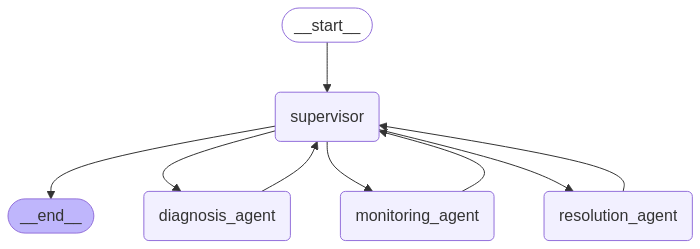

In [ ]:
from IPython.display import display, Image

display(Image(aws_monitoring_workflow.get_graph().draw_mermaid_png()))



### Invoke the graph

In [ ]:
def start_workflow(user_query: str):
    """Start the AWS monitoring workflow with a user query."""
    initial_message = HumanMessage(content=user_query)
    return aws_monitoring_workflow.invoke({"messages": [initial_message]})

In [ ]:
result = start_workflow("Check the available EC2 instances and diagnose it accordingly")
print(result)

/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_11325/470374512.py:56: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  StartTime=datetime.utcnow() - timedelta(minutes=10),
/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_11325/470374512.py:57: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  EndTime=datetime.utcnow()
/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_11325/470374512.py:56: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  StartTime=datetime.utcnow() - timedelta(minutes=10),
/var/fo

AttributeError: 'AddableValuesDict' object has no attribute 'content'